In [1]:
%cd /run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough

/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough


In [2]:
import argparse, inspect, json, os, pickle, socket, subprocess, warnings, random, math, sys, importlib.util, shutil, tempfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from sklearn.metrics import accuracy_score, auc, balanced_accuracy_score, confusion_matrix, f1_score, roc_auc_score, roc_curve
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from tensorboard.backend.event_processing import event_accumulator
from torch.amp import GradScaler
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
from transformers import AutoConfig, AutoFeatureExtractor, AutoModel, get_linear_schedule_with_warmup

import commons, models, utils
from cough_datasets import CoughDatasets, CoughDatasetsCollate
from wrapper.wav2vec import Wav2VecWrapper
from wrapper.wavlm_plus import WavLMWrapper
from wrapper.whisper import WhisperWrapper

import warnings
warnings.simplefilter("ignore", UserWarning)

def grl_lambda_schedule(current_step, max_steps, max_lambda=1.0):
    """Gradually increases λ from 0 to max_lambda."""
    if current_step < 1200:
        return 0.01
    p = (current_step - 1200) / (max_steps - 1200)
    p = min(max(p, 0.0), 1.0)
    return max_lambda * (2. / (1. + math.exp(-10 * p)) - 1.)

# =============================================================
# SECTION: Intialize Data
# =============================================================
parser = argparse.ArgumentParser()
parser.add_argument("--model_name", type=str, default="try_wavlmlora_downstream")

args_list = [
    "--model_name", "nonstatify_augmentmultimasklow4num_resnet_spectogram"
]
args = parser.parse_args(args_list)

model_dir = os.path.join("./logs", args.model_name)
if not os.path.exists(model_dir):
    os.makedirs(model_dir)\

config_save_path = os.path.join(model_dir, "config.json")
with open(config_save_path, "r") as f:
    data = f.read()

config = json.loads(data)
  
hps = utils.HParams(**config)
hps.model_dir = model_dir

BATCH_SIZE = hps.train.batch_size
ACCUMULATION_STEP = hps.train.accumulation_steps
assert (ACCUMULATION_STEP > 0) and (BATCH_SIZE % ACCUMULATION_STEP == 0)
cur_bs = BATCH_SIZE // ACCUMULATION_STEP

# =============================================================
# SECTION: Loading Data
# =============================================================

df_longi = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/coda/longitudinal_original.csv')
#df_solic = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/coda/solicited_original.csv')

participant_mapping_longi = {participant: idx for idx, participant in enumerate(set(np.concatenate([df_longi['participant'].unique()])))} # df_solic['participant'].unique()
df_longi['participant'] = df_longi['participant'].map(participant_mapping_longi)
#df_solic['participant'] = df_solic['participant'].map(participant_mapping_longi)

gender_mapping_longi = {gender: idx for idx, gender in enumerate(df_longi['sex'].unique())}
df_longi['sex'] = df_longi['sex'].map(gender_mapping_longi)
#df_solic['sex'] = df_solic['sex'].map(gender_mapping_longi)

#df_longi_train, df_longi_val = utils.stratified_group_split(df_longi)
#df_solic_train, df_solic_val = utils.stratified_group_split(df_solic)

df_train, df_test = train_test_split(
    df_longi,
    test_size=0.2,
    stratify=df_longi[hps.data.target_column],
    random_state=42,
)
#df_train = pd.concat([df_longi_train, df_solic_train], ignore_index=True)
#df_test = pd.concat([df_longi_val, df_solic_val], ignore_index=True)

if hps.data.reorder_target:
    cols = hps.data.column_order
    df_train = df_train[cols]
    df_test = df_test[cols]

disease_codes = df_train[hps.data.target_column].unique().tolist()
class_frequencies = df_train[hps.data.target_column].value_counts().to_dict()
total_samples = len(df_train)
class_weights = {cls: total_samples / (len(disease_codes) * freq) if freq != 0 else 0 for cls, freq in class_frequencies.items()}
weights_list = [class_weights[cls] for cls in disease_codes]
class_weights_tensor = torch.tensor(weights_list, device='cuda', dtype=torch.float)
# =============================================================
# SECTION: Setup Logger, Dataloader
# =============================================================
collate_fn = CoughDatasetsCollate(hps.data.many_class)
train_dataset = CoughDatasets(df_train.values, hps.data, train=True)
val_dataset = CoughDatasets(df_test.values, hps.data, train=False)

train_loader = DataLoader(train_dataset, num_workers=28, shuffle=True, batch_size=cur_bs, pin_memory=True, drop_last=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, num_workers=28, shuffle=False, batch_size=hps.train.batch_size, pin_memory=True, drop_last=True, collate_fn=collate_fn)

ssl_model_type = hps.model.ssl_model_type.lower()
ssl_model = None

temp_path = tempfile.NamedTemporaryFile(suffix=".py", delete=False).name
shutil.copy(f"{model_dir}/model_net.py.bak", temp_path)
spec = importlib.util.spec_from_file_location("model_net", temp_path)
model_net = importlib.util.module_from_spec(spec)
sys.modules["model_net"] = model_net
spec.loader.exec_module(model_net)

hps.model.spk_dim = len(participant_mapping_longi)
pool_net = getattr(model_net, hps.model.pooling_model)
pool_model = pool_net(hps.model.feature_dim, **hps.model)

if ssl_model != None:
    ssl_model.model_pooling = pool_model
    pool_model = ssl_model

pool_model = pool_model.cuda()

_, _, _, _, epoch_str = utils.load_checkpoint(
    os.path.join(hps.model_dir, "best_pool.pth"),
    pool_model,
    None,
    None,
)

/run/media/fourier/Data1/Pras/Thesis_Nexus/.env_312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True
Use Data Augmentation
False
Use Data Augmentation


Eval val: 100%|██████████| 1012/1012 [00:36<00:00, 27.60it/s]


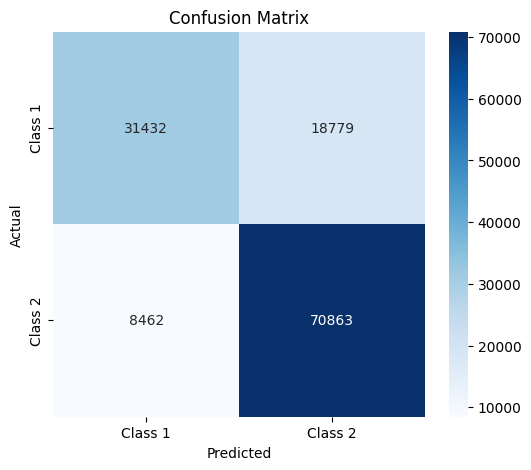

In [3]:
def evaluate_model(loader, split_name):
    pool_model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for _, (_, audio, attention_masks, dse_ids, _) in enumerate(tqdm(loader, desc=f"Eval {split_name}")):
            audio = audio.cuda(non_blocking=True).float().squeeze(1)
            attention_masks = attention_masks.cuda(non_blocking=True).float()
            dse_ids = dse_ids.cuda(non_blocking=True).float()

            logits = pool_model(audio, attention_mask=attention_masks)["disease_logits"]
            preds = torch.argmax(logits, dim=1)
            labels = np.argmax(dse_ids.cpu().numpy(), axis=-1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels)

    all_labels, all_preds = np.array(all_labels), np.array(all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    n_classes = cm.shape[0]
    class_labels = [f"Class {i+1}" for i in range(n_classes)]

    acc = accuracy_score(all_labels, all_preds)
    b_acc = balanced_accuracy_score(all_labels, all_preds)
    sens = np.mean([cm[i, i] / cm[i, :].sum() for i in range(n_classes) if cm[i, :].sum() > 0])
    spec = np.mean([(cm.sum() - cm[i, :].sum() - cm[:, i].sum() + cm[i, i]) / (cm.sum() - cm[i, :].sum())
                    for i in range(n_classes) if (cm.sum() - cm[i, :].sum()) > 0])

    if split_name == "val":
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=class_labels, yticklabels=class_labels)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")

    return acc, b_acc, sens, spec

val_metrics = evaluate_model(val_loader, "val")

In [55]:
df_train_ukcovid = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/ukcovid19/metadata.csv.train')
df_test_ukcovid = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/ukcovid19/metadata.csv.val')
df_train_ukcovid = df_train_ukcovid.rename(columns={"file_path": "path_file", 'covid_test_result': 'disease_status', 'gender': 'sex', 'participant_identifier': 'participant'})
df_test_ukcovid = df_test_ukcovid.rename(columns={"file_path": "path_file", 'covid_test_result': 'disease_status', 'gender': 'sex', 'participant_identifier': 'participant'})

In [56]:
df_longi = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/coda/longitudinal_original.csv')
df_longi = (
    df_longi.groupby('participant', group_keys=False)
    .apply(lambda x: x.sample(n=50, random_state=42) if len(x) > 50 else x)
)
df_solic = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/coda/solicited_original.csv')

/tmp/ipykernel_495654/3899728085.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=50, random_state=42) if len(x) > 50 else x)


In [57]:
df_tbscreen = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/TBscreen_Dataset/metadata_longitudinal.csv')
df_tbscreen = (
    df_tbscreen.groupby('participant', group_keys=False)
    .apply(lambda x: x.sample(n=50, random_state=42) if len(x) > 50 else x)
)

df_train_tbscreen = df_tbscreen[df_tbscreen['split'] == 'train'].reset_index(drop=True)
df_test_tbscreen   = df_tbscreen[df_tbscreen['split'] == 'validation'].reset_index(drop=True)

/tmp/ipykernel_495654/2442114239.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=50, random_state=42) if len(x) > 50 else x)


In [61]:
cols = ["path_file", "disease_status", "sex", "participant"]
df_longi = df_longi.rename(columns={"tb_status": "disease_status"})
df_solic = df_solic.rename(columns={"tb_status": "disease_status"})
df_longi = df_longi[cols]
df_solic = df_solic[cols]

df_train_tbscreen = df_train_tbscreen[["path_file", "disease_status", "sex", "participant"]]
df_test_tbscreen = df_test_tbscreen[["path_file", "disease_status", "sex", "participant"]]

df_train_ukcovid = df_train_ukcovid[["path_file", "disease_status", "sex", "participant"]]
df_test_ukcovid = df_test_ukcovid[["path_file", "disease_status", "sex", "participant"]]

df_train = pd.concat([df_longi, df_train_tbscreen, df_train_ukcovid], ignore_index=True)
df_test  = pd.concat([df_solic, df_test_tbscreen, df_test_ukcovid], ignore_index=True)

df_train['sex'] = df_train['sex'].replace({'Male': 0, 'Female': 1})
df_test['sex']  = df_test['sex'].replace({'Male': 0, 'Female': 1})

df_train['disease_status'] = df_train['disease_status'].replace(4, 0)
df_test['disease_status'] = df_test['disease_status'].replace(4, 0)

/tmp/ipykernel_495654/900400731.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['sex'] = df_train['sex'].replace({'Male': 0, 'Female': 1})
/tmp/ipykernel_495654/900400731.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['sex']  = df_test['sex'].replace({'Male': 0, 'Female': 1})


In [73]:
df_train['disease_status'].value_counts()

disease_status
0    75509
2    38460
1     9138
Name: count, dtype: int64

In [ ]:
import matplotlib.pyplot as plt

# Count how many times each participant appears
counts = df_test_ukcovid['participant'].value_counts()

# Plot histogram
plt.figure(figsize=(8, 4))
plt.hist(counts, bins=30)
plt.xlabel('Number of recordings per participant')
plt.ylabel('Number of participants')
plt.title('Histogram of recordings per participant')
plt.show()


,path_file,tb_status,sex,participant,disease_status
0,/run/media/fourier/Data1/Pras/DatabaseLLM/coda...,1.0,Female,CODA_TB_0002,NaN
1,/run/media/fourier/Data1/Pras/DatabaseLLM/coda...,1.0,Female,CODA_TB_0002,NaN
2,/run/media/fourier/Data1/Pras/DatabaseLLM/coda...,1.0,Female,CODA_TB_0002,NaN
3,/run/media/fourier/Data1/Pras/DatabaseLLM/coda...,1.0,Female,CODA_TB_0002,NaN
4,/run/media/fourier/Data1/Pras/DatabaseLLM/coda...,0.0,Male,CODA_TB_0003,NaN
...,...,...,...,...,...
123102,/run/media/fourier/Data1/Pras/DatabaseLLM/ukco...,NaN,Male,P0030938,2.0
123103,/run/media/fourier/Data1/Pras/DatabaseLLM/ukco...,NaN,Male,P0030938,2.0
123104,/run/media/fourier/Data1/Pras/DatabaseLLM/ukco...,NaN,Male,P0030938,2.0
123105,/run/media/fourier/Data1/Pras/DatabaseLLM/ukco...,NaN,Male,P0030938,2.0
